In [32]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

In [33]:
from src.code import Roost

import numpy as np
import matplotlib.pyplot as plt

In [34]:
np.random.seed(47)

roost = Roost(n=30, number_of_birds=450)
print(len(roost.agents))

450


In [35]:
for bird in roost.agents:
    bird.call_cells = 8
    bird.threshold = 1

    if np.random.random() < 0.1:
        bird.calling = True

roost.update_calls()
roost.update_takeoffs()

In [42]:
def draw_roost(roost):
    
    plt.figure(figsize=(7,7))

    taking_off = 0

    for bird in roost.agents:
        row,col = bird.loc

        if bird.state == "taking_off":
            color = "orange"
            taking_off += 1

        elif bird.calling:
            color = "red"

        else:
            color = "black"

        plt.plot(
            col + 0.5,
            row + 0.5,
            "o",
            color=color,
            markersize=4)

    plt.xlim(0,roost.n)
    plt.ylim(0,roost.n)
    plt.gca().set_aspect("equal")
    plt.xlabel("Col(forest)")
    plt.ylabel("Row(forest)")
    plt.plot([],[],"o",color="black",label="Quiet jackdaw")
    plt.plot([],[],"o",color="red",label="Calling jackdaw(still in roost,not take off)")
    plt.plot([],[],"o",color="orange",label="Take off jackdaw")
    plt.legend(loc="upper left",bbox_to_anchor=(1.02,1))
    plt.title(f"Taking off:{taking_off}/{len(roost.agents)}")
    plt.show()

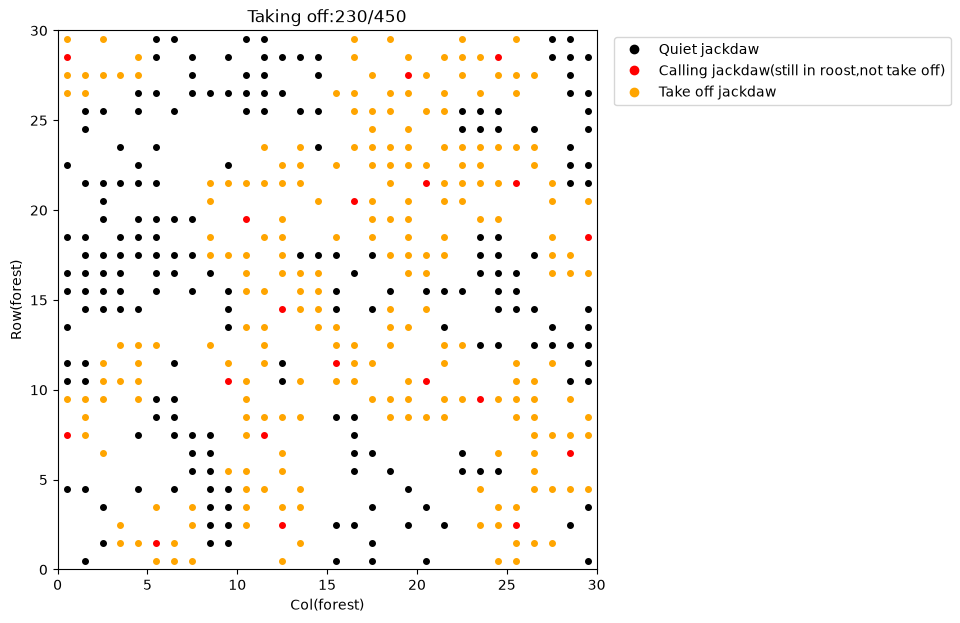

In [43]:
draw_roost(roost)

for i in range(32):
    # After 2 time step the voice of jackdaw rise 1 cell,gow slowly
    roost.step(grow_every=2)

    if roost.time in [8, 16, 32]:
        draw_roost(roost)


In [17]:
roost.step(grow_every=2)

print("Step in time:",roost.time

Step in time: 33


In [4]:
#let's add some calling

caller = roost.agents[0]
caller.calling = True
caller.call_cells = 8

roost.update_calls()
roost.update_takeoffs()

print("calling jackdaws:",caller.loc)
print("Cells receive calls:", np.count_nonzero(roost.calls))

calling jackdaws: (17, 12)
Cells receive calls: 8


In [5]:
caller.call_cells = min(caller.call_cells + 1,24)
roost.update_calls()
print("Cells receive calls:", np.count_nonzero(roost.calls))

Cells receive calls: 9


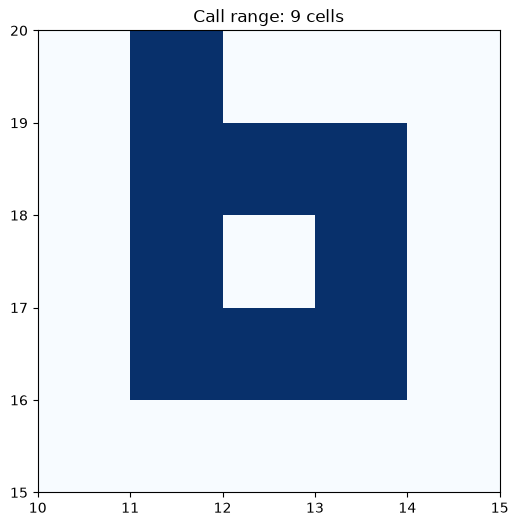

In [6]:
row,col = caller.loc

plt.figure(figsize=(6,6))

plt.imshow(
    roost.calls,
    origin="lower",
    extent=(0,roost.n,0,roost.n),
    cmap="Blues",
    vmin=0,vmax=1
)

plt.plot(
    col + 0.5, row + 0.5,
    markerfacecolor="none",
    markeredgecolor="red",
    markersize=12
)

plt.xlim(max(0,col - 2),min(roost.n,col + 3))
plt.ylim(max(0,row - 2),min(roost.n,row + 3))

covered_cells = np.count_nonzero(roost.calls)
plt.title(f"Call range: {covered_cells} cells")
          
plt.show()


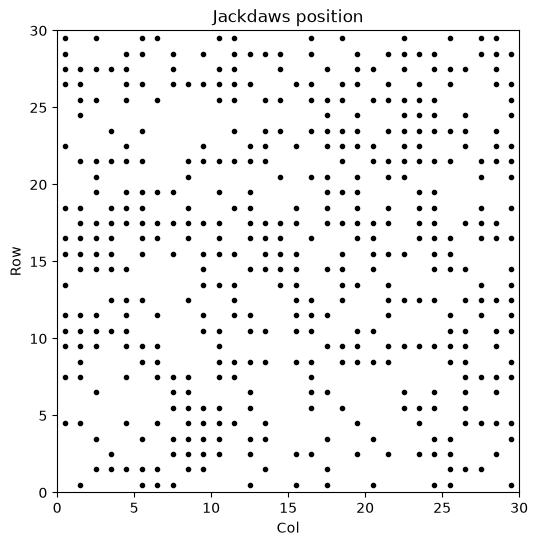

In [8]:
rows = []
cols = []

for bird in roost.agents:
    row,col = bird.loc
    rows.append(row + 0.5)
    cols.append(col + 0.5)

plt.figure(figsize=(6,6))

plt.plot(cols,rows,".",color="black")

plt.xlim(0,roost.n)
plt.ylim(0,roost.n)
plt.gca().set_aspect("equal")

plt.xlabel("Col")
plt.ylabel("Row")
plt.title("Jackdaws position")

plt.show()